In [3]:
from pathlib import Path
import shutil

source1 = Path("../data/raw/HAM10000_images_part_1")
source2 = Path("../data/raw/HAM10000_images_part_2")
destination = Path("../data/images")

destination.mkdir(exist_ok=True)

for img in source1.glob("*.jpg"):
    shutil.copy(img, destination / img.name)

for img in source2.glob("*.jpg"):
    shutil.copy(img, destination / img.name)

print("Images copied successfully!")

Images copied successfully!


In [4]:
from pathlib import Path

images = list(Path("../data/images").glob("*.jpg"))

print("Total Images:", len(images))

Total Images: 10015


In [5]:
# ==========================
# Load Metadata
# ==========================

import pandas as pd

print("[INFO] Loading metadata...")

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print("[SUCCESS] Metadata loaded successfully.")

[INFO] Loading metadata...
[SUCCESS] Metadata loaded successfully.


In [9]:
# ==========================
# Display First Five Rows
# ==========================

print("[INFO] Displaying first 5 rows...")

df.head(20)

[INFO] Displaying first 5 rows...


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


In [7]:
# ==========================
# Dataset Shape
# ==========================

print("[INFO] Checking dataset dimensions...")

rows, columns = df.shape

print(f"[SUCCESS] Number of rows    : {rows}")
print(f"[SUCCESS] Number of columns : {columns}")

[INFO] Checking dataset dimensions...
[SUCCESS] Number of rows    : 10015
[SUCCESS] Number of columns : 7


In [8]:
# ==========================
# Column Names
# ==========================

print("[INFO] Displaying column names...")

for column in df.columns:
    print(column)

[INFO] Displaying column names...
lesion_id
image_id
dx
dx_type
age
sex
localization


In [10]:
# ==========================
# Dataset Information
# ==========================

print("[INFO] Displaying dataset information...")

df.info()

[INFO] Displaying dataset information...
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 990.6 KB


In [11]:
# ==========================================
# STEP 5: MISSING VALUES ANALYSIS
# ==========================================

print("=" * 60)
print("[INFO] Starting missing values analysis...")
print("=" * 60)

missing_values = df.isnull().sum()

print("[LOADING] Checking each column...")

for column, value in missing_values.items():
    print(f"{column:<15} : {value}")

print("-" * 60)

total_missing = missing_values.sum()

print(f"[INFO] Total missing values : {total_missing}")

if total_missing > 0:
    print("[WARNING] Missing values detected.")
else:
    print("[SUCCESS] No missing values found.")

print("=" * 60)
print("[SUCCESS] Missing values analysis completed.")
print("=" * 60)

[INFO] Starting missing values analysis...
[LOADING] Checking each column...
lesion_id       : 0
image_id        : 0
dx              : 0
dx_type         : 0
age             : 57
sex             : 0
localization    : 0
------------------------------------------------------------
[INFO] Total missing values : 57
[WARNING] Missing values detected.
[SUCCESS] Missing values analysis completed.


In [12]:
print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] lesion_id has no missing values.")
print("[✓] image_id has no missing values.")
print("[✓] dx has no missing values.")
print("[✓] dx_type has no missing values.")
print("[WARNING] age contains 57 missing values.")
print("[✓] sex has no missing values.")
print("[✓] localization has no missing values.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] lesion_id has no missing values.
[✓] image_id has no missing values.
[✓] dx has no missing values.
[✓] dx_type has no missing values.
[WARNING] age contains 57 missing values.
[✓] sex has no missing values.
[✓] localization has no missing values.
[SUCCESS] Observation completed.


In [13]:
# ==========================================
# STEP 6: CLASS DISTRIBUTION
# ==========================================

print("=" * 60)
print("[INFO] Starting class distribution analysis...")
print("=" * 60)

class_distribution = df["dx"].value_counts()

print("[LOADING] Counting samples per class...\n")

for label, count in class_distribution.items():
    print(f"{label:<10} : {count}")

print("\n" + "=" * 60)
print("[SUCCESS] Class distribution analysis completed.")
print("=" * 60)

[INFO] Starting class distribution analysis...
[LOADING] Counting samples per class...

nv         : 6705
mel        : 1113
bkl        : 1099
bcc        : 514
akiec      : 327
vasc       : 142
df         : 115

[SUCCESS] Class distribution analysis completed.


In [14]:
# ==========================================
# OBSERVATIONS
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] 7 skin lesion classes found.")
print("[✓] Majority class : nv (6705 samples)")
print("[✓] Minority class : df (115 samples)")
print("[WARNING] Dataset is highly imbalanced.")
print("[INFO] Data augmentation will be used later.")

print("=" * 60)
print("[SUCCESS] Observation completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] 7 skin lesion classes found.
[✓] Majority class : nv (6705 samples)
[✓] Minority class : df (115 samples)
[WARNING] Dataset is highly imbalanced.
[INFO] Data augmentation will be used later.
[SUCCESS] Observation completed.


# Step 7: Visualize Class Distribution

Goal:
- Visualize the number of samples in each class.
- Identify majority and minority classes.

[INFO] Creating class distribution plot...


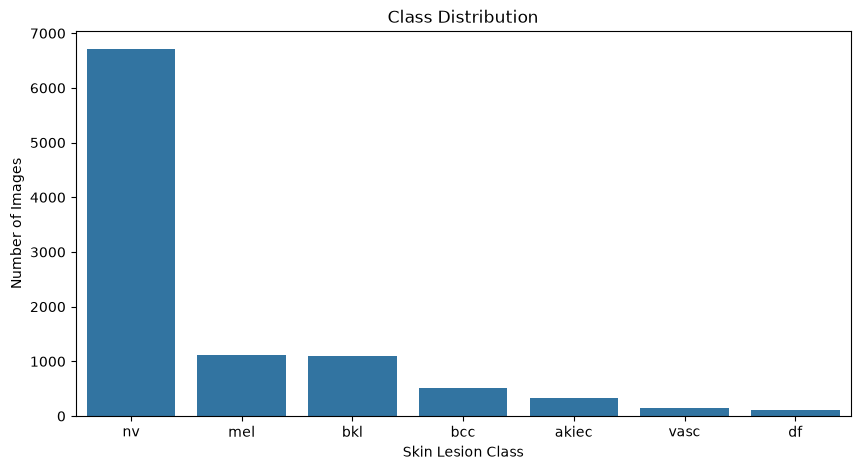

[SUCCESS] Visualization completed.


In [16]:
# ==========================================
# STEP 7: CLASS DISTRIBUTION VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
print("=" * 60)
print("[INFO] Creating class distribution plot...")
print("=" * 60)

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='dx',
    order=df['dx'].value_counts().index
)

plt.title("Class Distribution")
plt.xlabel("Skin Lesion Class")
plt.ylabel("Number of Images")

plt.show()

print("[SUCCESS] Visualization completed.")

[INFO] Creating age distribution plot...


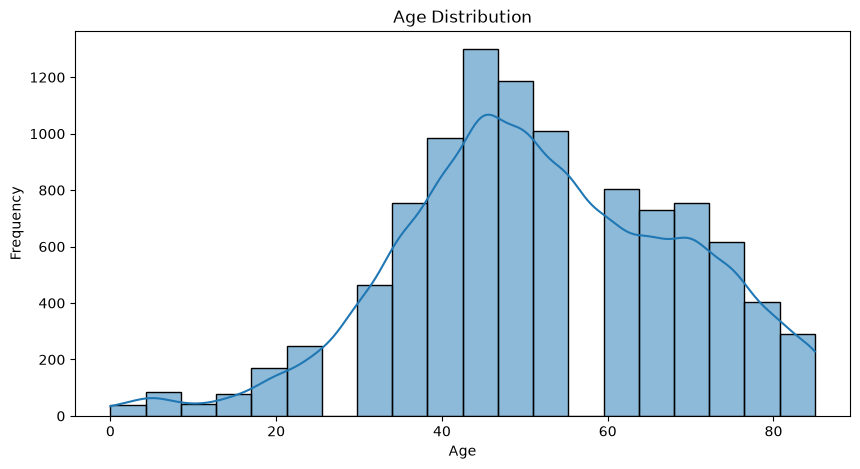

[SUCCESS] Age distribution plot created.


In [17]:
# ==========================================
# STEP 8: AGE DISTRIBUTION
# ==========================================

print("=" * 60)
print("[INFO] Creating age distribution plot...")
print("=" * 60)

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

print("[SUCCESS] Age distribution plot created.")
print("=" * 60)

In [18]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Most patients are between 35 and 60 years old.")
print("[✓] Peak age is around 45-50 years.")
print("[✓] Very few young patients (<20 years).")
print("[✓] Some patients are older than 80 years.")
print("[✓] No significant outliers detected.")

print("=" * 60)
print("[SUCCESS] Age distribution analysis completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Most patients are between 35 and 60 years old.
[✓] Peak age is around 45-50 years.
[✓] Very few young patients (<20 years).
[✓] Some patients are older than 80 years.
[✓] No significant outliers detected.
[SUCCESS] Age distribution analysis completed.


[INFO] Creating gender distribution plot...


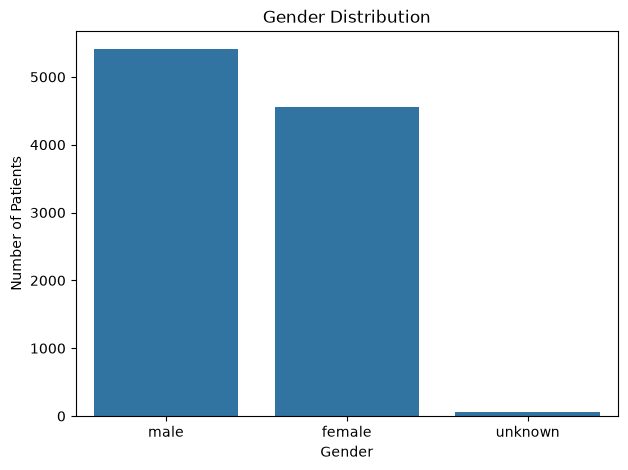

[SUCCESS] Gender distribution plot created.


In [19]:
# ==========================================
# STEP 9: GENDER DISTRIBUTION
# ==========================================

print("=" * 60)
print("[INFO] Creating gender distribution plot...")
print("=" * 60)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sex",
    order=df["sex"].value_counts().index
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

print("[SUCCESS] Gender distribution plot created.")
print("=" * 60)

In [20]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Male patients are slightly more than female patients.")
print("[✓] Gender distribution is fairly balanced.")
print("[✓] Very few samples have unknown gender.")
print("[✓] Gender imbalance is not a major concern.")

print("=" * 60)
print("[SUCCESS] Gender distribution analysis completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Male patients are slightly more than female patients.
[✓] Gender distribution is fairly balanced.
[✓] Very few samples have unknown gender.
[✓] Gender imbalance is not a major concern.
[SUCCESS] Gender distribution analysis completed.


[INFO] Creating localization distribution plot...


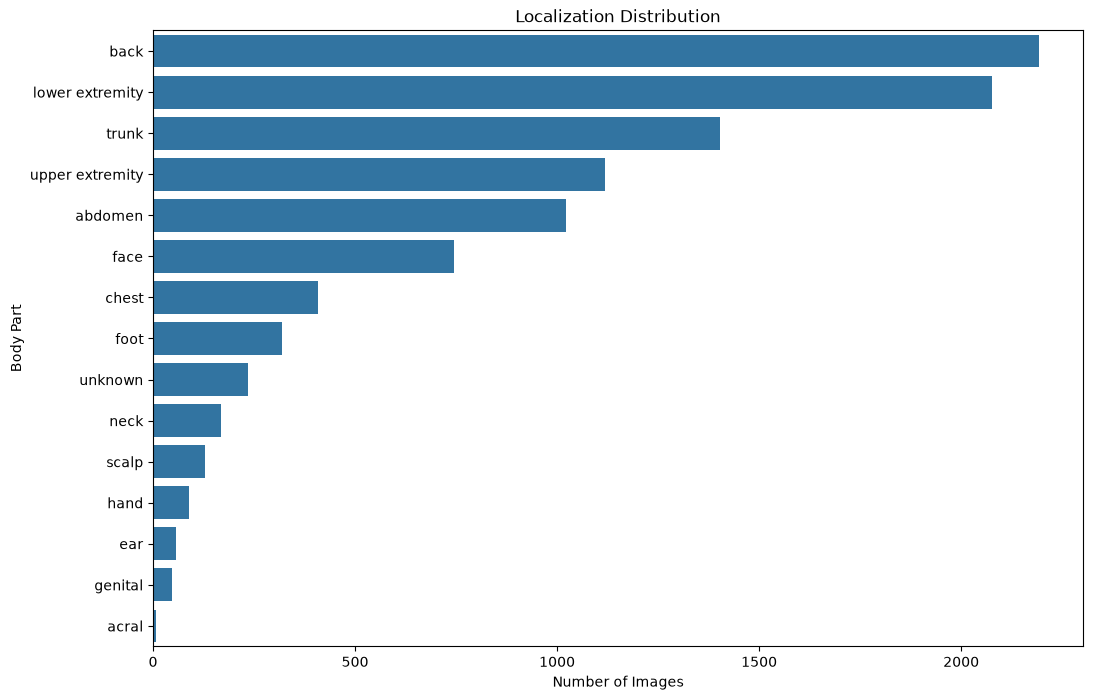

[SUCCESS] Localization distribution plot created.


In [21]:
# ==========================================
# STEP 10: LOCALIZATION DISTRIBUTION
# ==========================================

print("=" * 60)
print("[INFO] Creating localization distribution plot...")
print("=" * 60)

plt.figure(figsize=(12,8))

sns.countplot(
    data=df,
    y="localization",
    order=df["localization"].value_counts().index
)

plt.title("Localization Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Body Part")

plt.show()

print("[SUCCESS] Localization distribution plot created.")
print("=" * 60)

In [22]:
# ==========================================
# OBSERVATION REPORT
# ==========================================

print("=" * 60)
print("[OBSERVATION REPORT]")
print("=" * 60)

print("[✓] Back is the most common lesion location.")
print("[✓] Lower extremity is the second most common location.")
print("[✓] Trunk and upper extremity contain many samples.")
print("[✓] Ear, genital, and acral regions have very few samples.")
print("[INFO] Body location distribution is uneven.")

print("=" * 60)
print("[SUCCESS] Localization analysis completed.")
print("=" * 60)

[OBSERVATION REPORT]
[✓] Back is the most common lesion location.
[✓] Lower extremity is the second most common location.
[✓] Trunk and upper extremity contain many samples.
[✓] Ear, genital, and acral regions have very few samples.
[INFO] Body location distribution is uneven.
[SUCCESS] Localization analysis completed.


In [23]:
# ==========================================
# STEP 11: SAMPLE IMAGES
# ==========================================

print("=" * 60)
print("[INFO] Preparing sample images...")
print("=" * 60)

classes = df["dx"].unique()

print("[INFO] Classes found:")
print(classes)

print("=" * 60)

[INFO] Preparing sample images...
[INFO] Classes found:
<ArrowStringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str


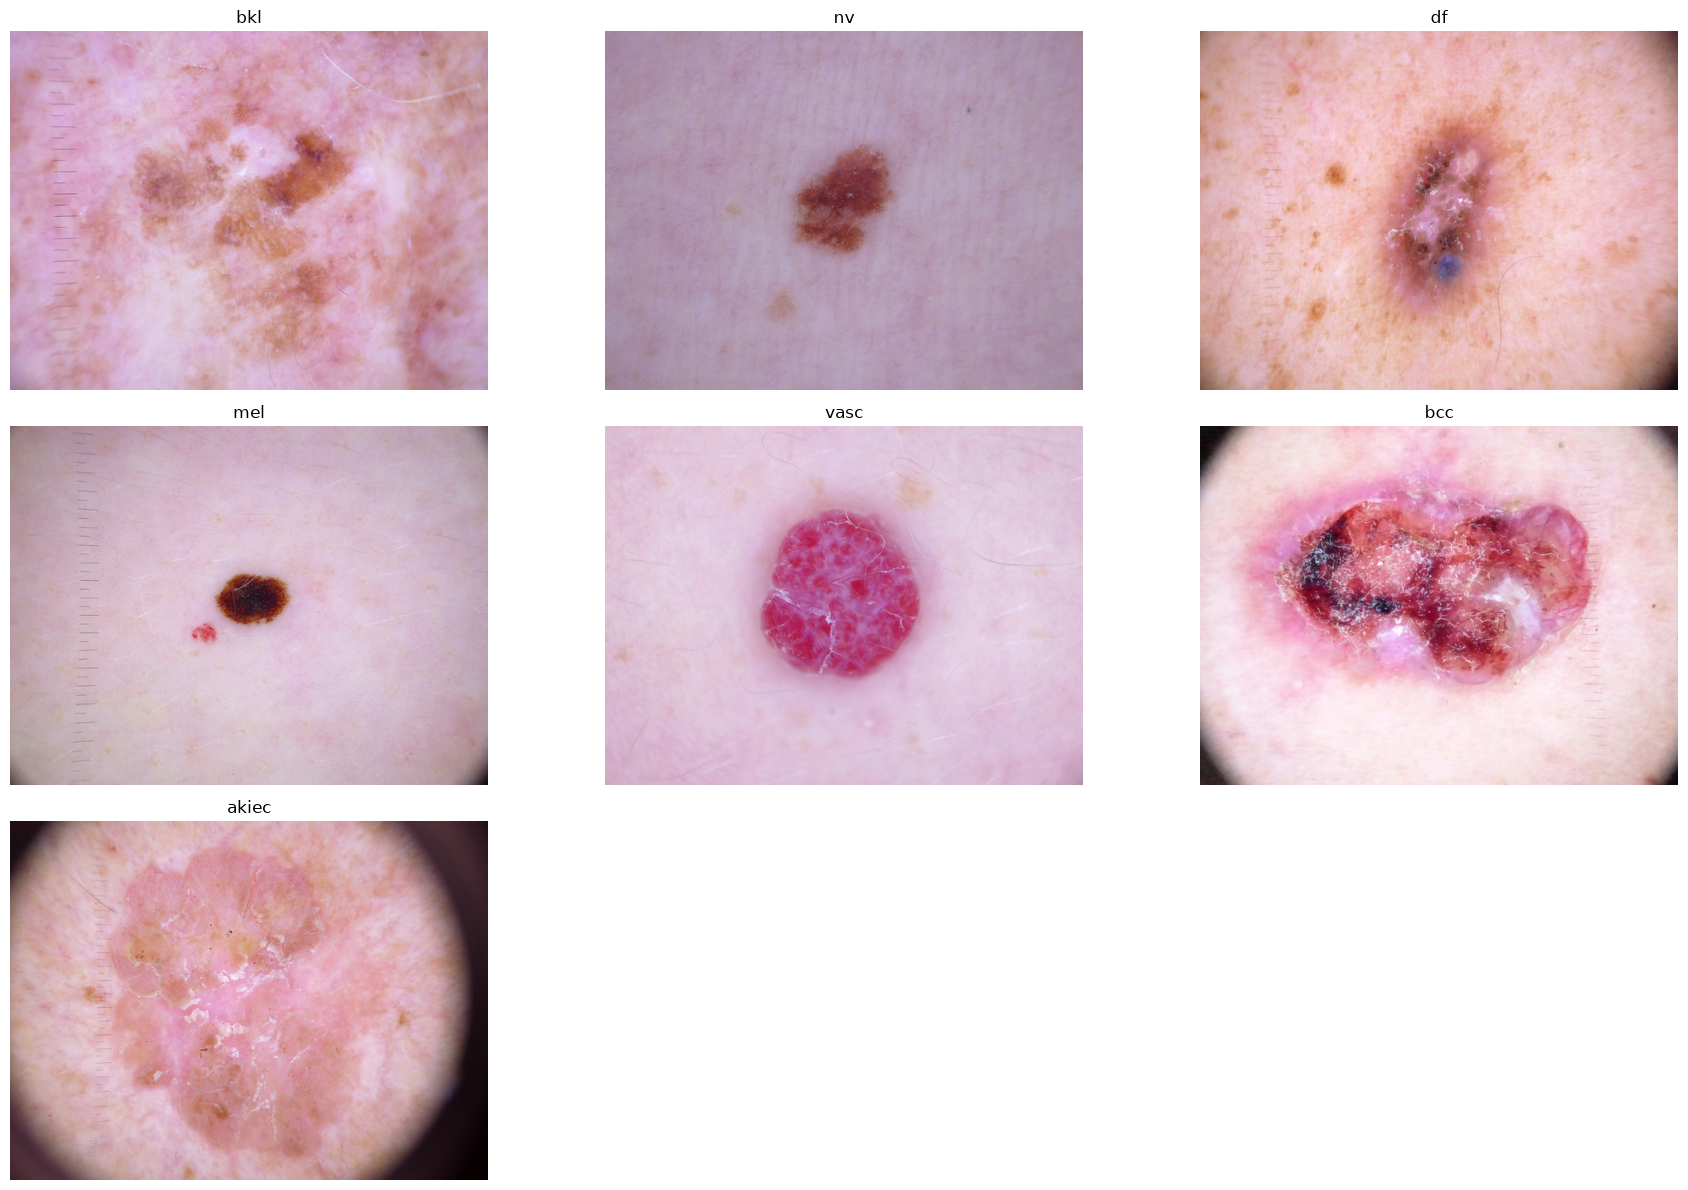

[SUCCESS] Sample images displayed successfully.


In [24]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

plt.figure(figsize=(18,12))

for i, lesion_class in enumerate(classes):

    # Select first image from each class
    image_id = df[df["dx"] == lesion_class]["image_id"].iloc[0]

    image_path = Path("../data/images") / f"{image_id}.jpg"

    image = Image.open(image_path)

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(lesion_class)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("[SUCCESS] Sample images displayed successfully.")

# Step 12: EDA Summary

## Key Findings

### Dataset Information
- Total images: 10015
- Total features: 7

### Missing Values
- 57 missing values in age column.
- No missing values in other columns.

### Class Distribution
- 7 skin lesion classes are present.
- Dataset is highly imbalanced.
- Majority class: nv (6705 samples).
- Minority class: df (115 samples).

### Age Distribution
- Most patients are between 35 and 60 years old.
- Peak age is around 45–50 years.

### Gender Distribution
- Male patients are slightly more than female patients.
- Gender distribution is fairly balanced.

### Localization Distribution
- Most lesions occur on the back.
- Lower extremity is the second most common location.

### Visual Inspection
- Several lesion classes appear visually similar.
- Classification may be challenging.
- Data augmentation and transfer learning will be important.

## Future Work

During preprocessing:

- Handle missing age values.
- Encode labels.
- Perform train-validation-test split.
- Apply data augmentation.
- Create Dataset and DataLoader classes.

During training:

- Baseline CNN.
- ResNet50.
- EfficientNet-B0.
- Model comparison.